# Compare embedding distribution
This notebook computes the model embeddings for two data sets 

In [1]:
import pandas as pd
from gnn import create_tf_dataset, CustomPreprocessor, atom_features, bond_features, global_features
from  gnn import *
import nfp
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.pipeline import Pipeline
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.neighbors import NearestNeighbors

import tensorflow as tf
gpus = tf.config.experimental.list_physical_devices('GPU')
print(tf.config.list_physical_devices('GPU'))

if len(gpus) > 0:
    tf.config.experimental.set_memory_growth(gpus[0], True)

import os
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'
os.environ['TF_MKL_REUSE_PRIMITIVE_MEMORY'] = '0'



[]


In [2]:
# Load the data
df_dmf = pd.read_csv('/home/nanta/Solv_GNN_SSD/data/DMF_as_solvent/Solv_GNN_SSD_train_DMF_as_solvent.csv')
# df_dmf = df_dmf[df_dmf['can_smiles_solvent']=='CN(C)C=O'][['can_smiles_solute','can_smiles_solvent','DGsolv']][:100]
# dff2 path comes from notebooks/data.py.ipynb
dff2 = pd.read_csv('/home/nanta/Redox_mediator_screening/data/Filtered_data/filter2.csv.gz', compression='gzip')
# dff2 = pd.read_csv('/home/nanta/Redox_mediator_screening/data/Filtered_data/filter1_pre_sol_pred_results.csv.gz', compression='gzip')
# df_aug = df_aug[df_aug['can_smiles_solvent']=='CN(C)C=O'][['can_smiles_solute','can_smiles_solvent','DGsolv']][:100]
dff2 = dff2.sample(n=3000, random_state=42)
# rename columns for consistency
dff2.rename(columns={'predicted': 'solubility_predicted'}, inplace=True)
dff2 = dff2[['can_smiles_solute','can_smiles_solvent','DGsolv','solubility_predicted']]


/home/nanta/miniconda3/envs/tf24gpu/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3398: DtypeWarning: Columns (32,39) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [9]:
print(len(df_dmf), len(dff2))
print(df_dmf.columns)

3218 3000
Index(['solute', 'solvent', 'logS', 'DGsolv', 'Reference (DOI)', 'Comments',
       'can_smiles_solute', 'can_smiles_solvent', 'concat_smiles',
       'is_chonps_halogens', 'index', 'DGsolv_cosmo',
       'Atom_bond_type_overlap_with_exp', 'AE', 'Signed_Err'],
      dtype='object')


In [46]:
print(dff2.columns)
print(dff2.head())

Index(['can_smiles_solute', 'can_smiles_solvent', 'DGsolv',
       'solubility_predicted'],
      dtype='object')
                      can_smiles_solute can_smiles_solvent  DGsolv  \
261512  C1=CC=NC(=C1)C2=CC(C=CN2)(CO)CO           CN(C)C=O     NaN   
310109               C1=CC(=CN=C1)OCC=O           CN(C)C=O     NaN   
171101         COC(=O)C1=C(C=NC=C1Cl)Cl           CN(C)C=O     NaN   
391391          CN1N=CC(=N1)C2=NC=NC=C2           CN(C)C=O     NaN   
313644   CC1=CC(=C(C=C1)OCC(=O)N)C(=O)O           CN(C)C=O     NaN   

        solubility_predicted  
261512            -18.128742  
310109             -9.845778  
171101             -9.786279  
391391            -12.618115  
313644            -20.802547  


In [21]:
from tqdm import tqdm


# Load model and preprocessor
model = tf.keras.models.load_model('/home/nanta/Solv_GNN_SSD/model_files/SSD_models/student35/best_model.h5', custom_objects=nfp.custom_objects)
preprocessor = CustomPreprocessor(explicit_hs=False, atom_features=atom_features, bond_features=bond_features)
preprocessor.from_json('/home/nanta/Solv_GNN_SSD/model_files/SSD_models/student35/preprocessor.json')

extractor = tf.keras.Model(model.inputs, [model.get_layer('dense_22').input]) # layer after all message passing and then tf.concat
output_signature = (preprocessor.output_signature, tf.TensorSpec(shape=(), dtype=tf.float32), tf.TensorSpec(shape=(), dtype=tf.float32))

def embed_dataframe(df):
    ds = tf.data.Dataset.from_generator(
        lambda: create_tf_dataset(df, preprocessor, 1.0, False),
        output_signature=output_signature
    ).padded_batch(batch_size=len(df))
    # Use tqdm to show progress bar during prediction
    embedding = extractor.predict(ds, verbose=1)  # verbose=1 shows a progress bar
    embedding = embedding.squeeze()
    # select only the first 128 features (solute)
    embedding = embedding[:, :128]
    return pd.DataFrame(embedding, index=df.index)


# emb_aug = embed_dataframe(df_aug)
emb_dmf = embed_dataframe(df_dmf)
emb_dff2 = embed_dataframe(dff2)


1/1 [==============================] - 13s 13s/step


In [22]:
print(emb_dmf[0])

0      -1.295282
1       0.044575
2      -0.815935
3      -0.836426
4      -0.495878
          ...   
3213    1.118457
3214   -1.681354
3215   -0.910507
3216    1.346375
3217   -1.357369
Name: 0, Length: 3218, dtype: float32


## k-NN distance

### deployment set to training set

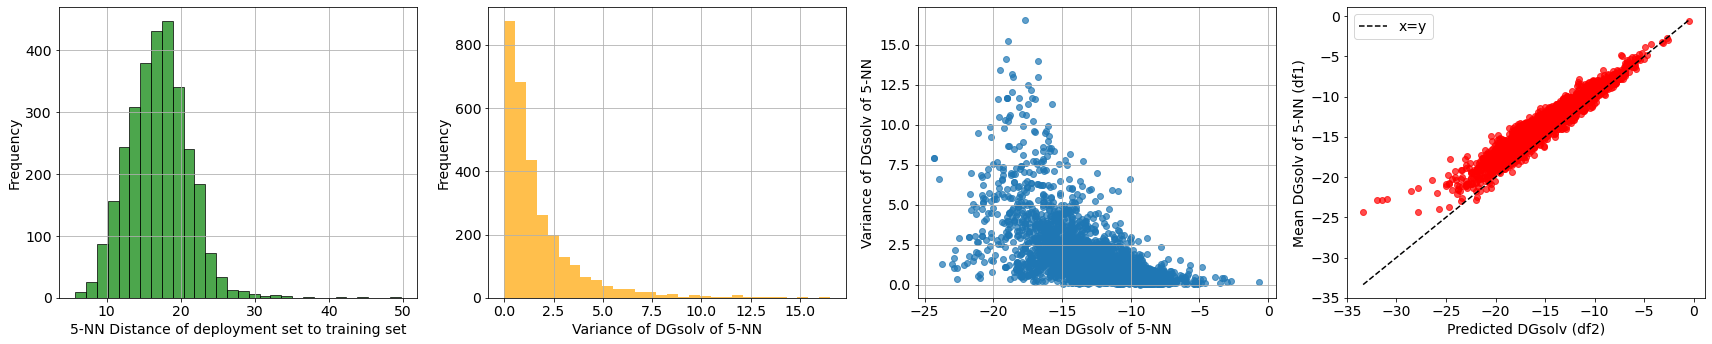

In [ ]:
from sklearn.neighbors import NearestNeighbors

def kNN_plot(emb1, emb2, df1, df2, n_neighbors=5):
    nn = NearestNeighbors(n_neighbors=n_neighbors, metric='euclidean')
    nn.fit(emb1)
    distances, indices = nn.kneighbors(emb2)

    nn_dgsolv = df1['DGsolv'].values[indices.flatten()]
    nn_dgsolv = nn_dgsolv.reshape(distances.shape)
    nn_dgsolv_mean = nn_dgsolv.mean(axis=1)
    nn_dgsolv_var = nn_dgsolv.var(axis=1)   

    fig, axs = plt.subplots(1, 4, figsize=(24, 5))

    # Plot distribution of the 5-NN distances (flattened)
    axs[0].hist(distances.flatten(), bins=30, alpha=0.7, color='green')
    # axs[0].hist(distances.mean(axis=1), bins=30, alpha=0.7, color='green', edgecolor='black')
    axs[0].set_xlabel(f'{n_neighbors}-NN Distance of deployment set to training set')
    axs[0].set_ylabel('Frequency')
    # axs[0].set_title('Distribution of 5-NN Distances (df2 to df1)')
    axs[0].grid()

    # Plot variance of DGsolv of the 5 nearest neighbors
    axs[1].hist(nn_dgsolv_var, bins=30, alpha=0.7, color='orange')
    axs[1].set_xlabel('Variance of DGsolv of 5-NN')
    axs[1].set_ylabel('Frequency')
    # axs[1].set_title('Variance of DGsolv of 5-NN (df2 to df1)')
    axs[1].grid()

    # Plot mean vs variance of DGsolv of the 5 nearest neighbors
    axs[2].scatter(nn_dgsolv_mean, nn_dgsolv_var, alpha=0.7)
    axs[2].set_xlabel('Mean DGsolv of 5-NN')
    axs[2].set_ylabel('Variance of DGsolv of 5-NN')
    # axs[2].set_title('Mean vs Variance of DGsolv (5-NN, df2 to df1)')
    axs[2].grid()

    # plot the DGsolv of df2 vs mean of the 5-NN
    axs[3].scatter(df2['solubility_predicted'].values, nn_dgsolv_mean, alpha=0.7, color='red')
    axs[3].set_xlabel('Predicted DGsolv (df2)')
    axs[3].set_ylabel('Mean DGsolv of 5-NN (df1)')
    axs[3].legend(['5-NN Mean', 'True Values'], loc='upper left')   
    axs[3].plot(
        [df2['solubility_predicted'].min(), df2['solubility_predicted'].max()],
        [df2['solubility_predicted'].min(), df2['solubility_predicted'].max()],
        'k--', label='x=y'
    )
    axs[3].legend()

    plt.tight_layout()
    plt.show()

# Compare embeddings
kNN_plot(emb_dmf, emb_dff2, df_dmf, dff2, n_neighbors=5)

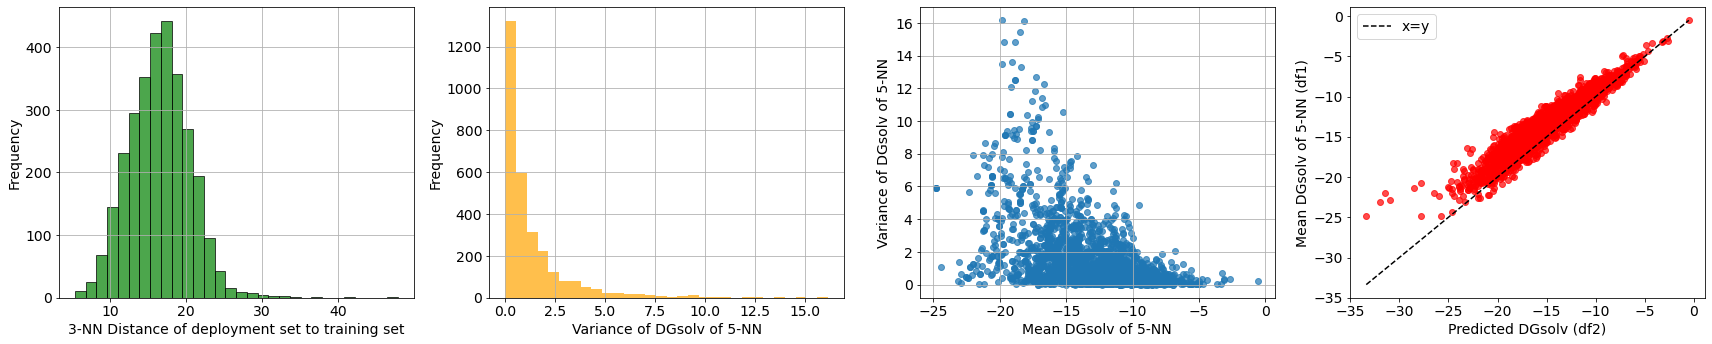

In [34]:
kNN_plot(emb_dmf, emb_dff2, df_dmf, dff2, n_neighbors=3)

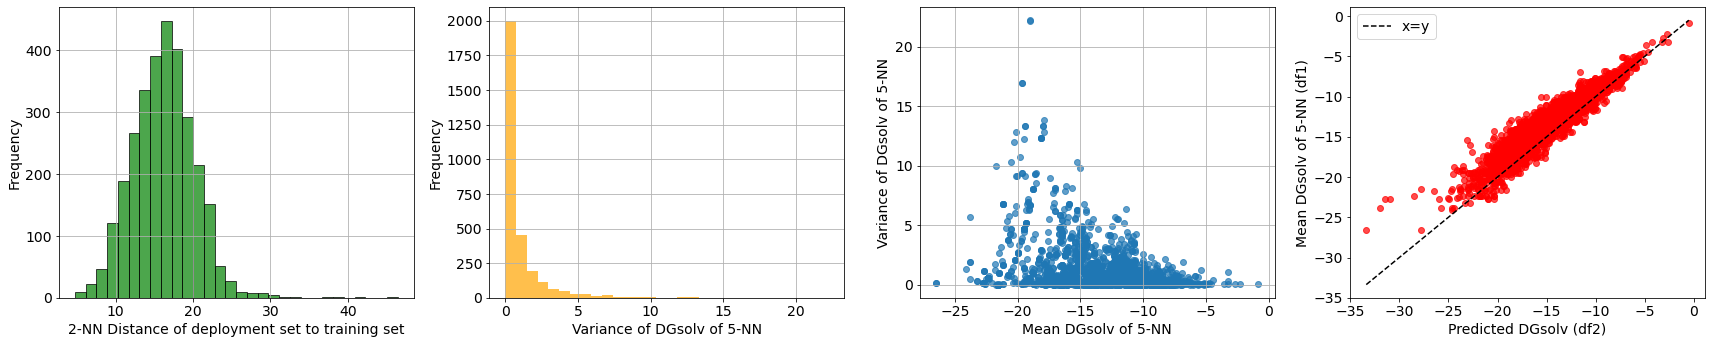

In [35]:
kNN_plot(emb_dmf, emb_dff2, df_dmf, dff2, n_neighbors=2)

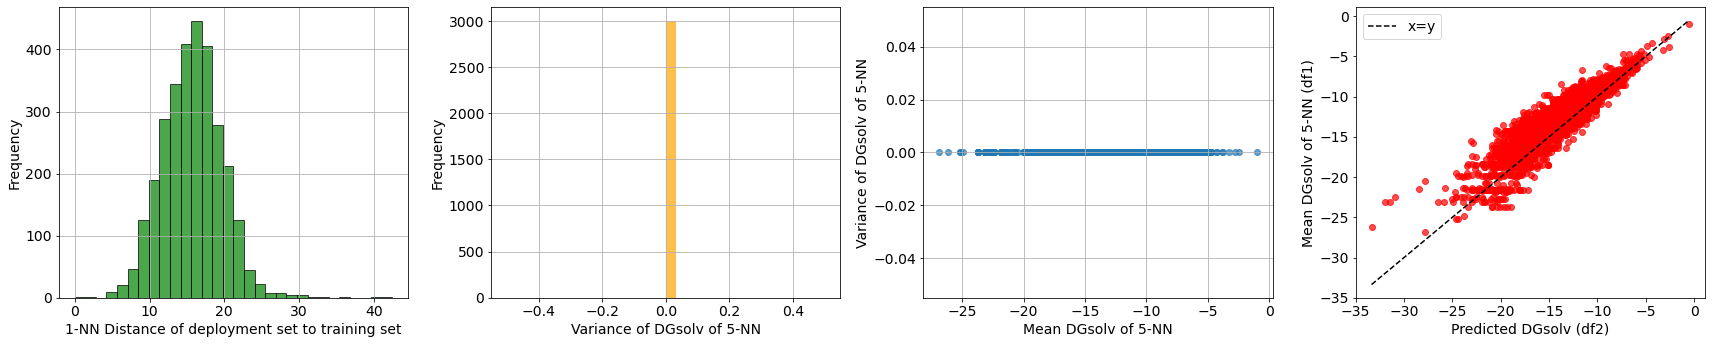

In [36]:
kNN_plot(emb_dmf, emb_dff2, df_dmf, dff2, n_neighbors=1)

### training set to training set

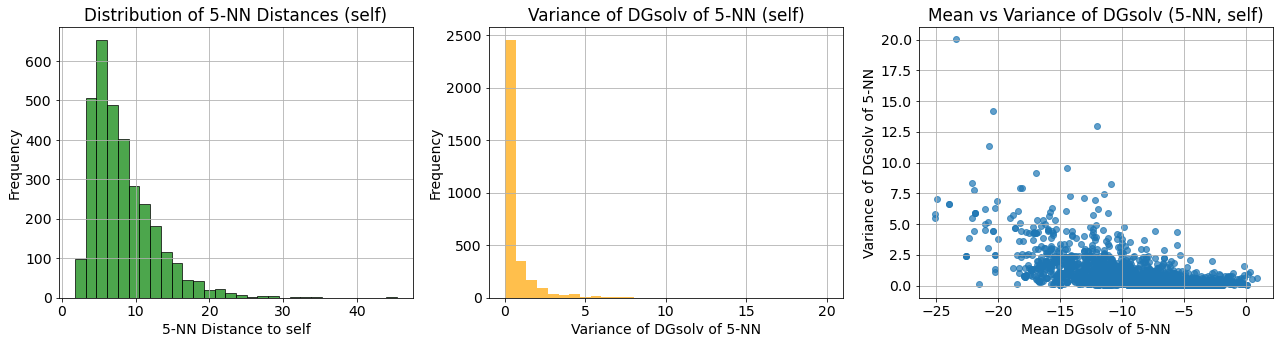

In [ ]:
def kNN_plot_self(emb1, df1, n_neighbors=5):
    nn = NearestNeighbors(n_neighbors=n_neighbors, metric='euclidean')
    nn.fit(emb1)
    distances, indices = nn.kneighbors(emb1)

    nn_dgsolv = df1['DGsolv'].values[indices.flatten()]
    nn_dgsolv = nn_dgsolv.reshape(distances.shape)
    nn_dgsolv_mean = nn_dgsolv.mean(axis=1)
    nn_dgsolv_var = nn_dgsolv.var(axis=1)   

    fig, axs = plt.subplots(1, 3, figsize=(18, 5))

    # Plot distribution of the 5-NN distances (flattened)
    axs[0].hist(distances.flatten(), bins=30, alpha=0.7, color='green')
    # axs[0].hist(distances.mean(axis=1), bins=30, alpha=0.7, color='green', edgecolor='black')
    axs[0].set_xlabel(f'{n_neighbors}-NN Distance to self')
    axs[0].set_ylabel('Frequency')
    axs[0].set_title(f'Distribution of {n_neighbors}-NN Distances (self)')
    axs[0].grid()

    # Plot variance of DGsolv of the 5 nearest neighbors
    axs[1].hist(nn_dgsolv_var, bins=30, alpha=0.7, color='orange')
    axs[1].set_xlabel(f'Variance of DGsolv of {n_neighbors}-NN')
    axs[1].set_ylabel('Frequency')
    axs[1].set_title(f'Variance of DGsolv of {n_neighbors}-NN (self)')
    axs[1].grid()

    # Plot mean vs variance of DGsolv of the 5 nearest neighbors
    axs[2].scatter(nn_dgsolv_mean, nn_dgsolv_var, alpha=0.7)
    axs[2].set_xlabel('Mean DGsolv of 5-NN')
    axs[2].set_ylabel(f'Variance of DGsolv of {n_neighbors}-NN')
    axs[2].set_title(f'Mean vs Variance of DGsolv ({n_neighbors}-NN, self)')
    axs[2].grid()

    plt.tight_layout()
    plt.show()

kNN_plot_self(emb_dmf, df_dmf, n_neighbors=5)

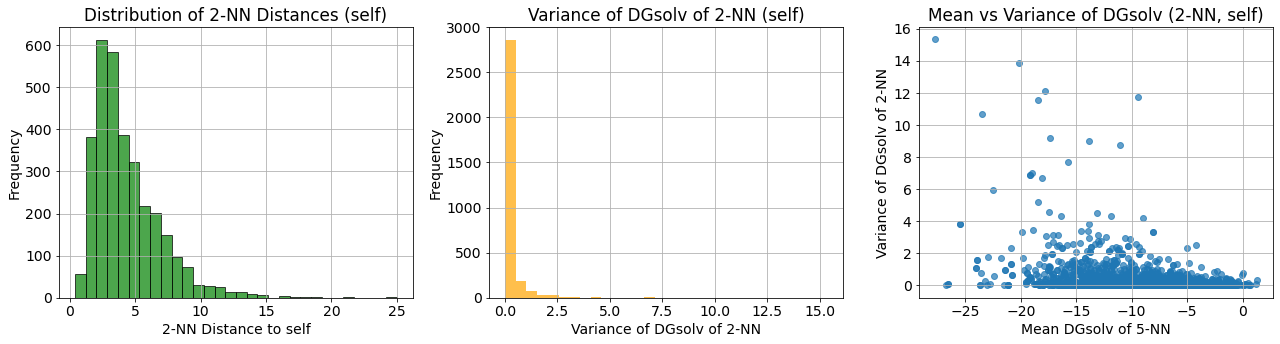

In [38]:
kNN_plot_self(emb_dmf, df_dmf, n_neighbors=2)

### compare

95% quantile of distances_self: 19.921843338012692
95% quantile of distances_other: 23.546581935882568


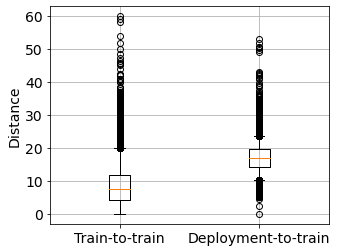

In [44]:
# boxplot comparing distance to self and distance to df2
def boxplot_distance(emb1, emb2, df1, df2, n_neighbors=5):
    nn_self = NearestNeighbors(n_neighbors=n_neighbors, metric='euclidean')
    nn_self.fit(emb1)
    distances_self, index = nn_self.kneighbors(emb1)
    # print quantiles of distances_self
    # print(f'50% quantile of distances_self: {np.quantile(distances_self, 0.5)}')
    # print(f'75% quantile of distances_self: {np.quantile(distances_self, 0.75)}')
    quan_95 = np.quantile(distances_self, 0.95)
    # quan_95 = np.quantile(distances_self.mean(axis=1), 0.95)
    print(f'95% quantile of distances_self: {quan_95}')
    # print(f'99% quantile of distances_self: {np.quantile(distances_self, 0.99)}')
    df1['distance_to_train'] = distances_self.mean(axis=1)
    df1['above_95_quantile'] = (df1['distance_to_train'] > np.quantile(distances_self, 0.95)).astype(int)
    df1['DGsolv_5NN'] = df1['DGsolv'].values[index.flatten()].reshape(distances_self.shape).mean(axis=1)
    df1['DGsolv_5NN_var'] = df1['DGsolv'].values[index.flatten()].reshape(distances_self.shape).var(axis=1)

    nn_other = NearestNeighbors(n_neighbors=n_neighbors, metric='euclidean')
    nn_other.fit(emb1)
    distances_other, index_o = nn_other.kneighbors(emb2)
    # print 95% quantile of distances_other
    print(f'95% quantile of distances_other: {np.quantile(distances_other, 0.95)}')
    df2['distance_to_train'] = distances_other.mean(axis=1)
    df2['above_95_quantile_train'] = (df2['distance_to_train'] > quan_95).astype(int)
    df2['DGsolv_5NN'] = df1['DGsolv'].values[index_o.flatten()].reshape(distances_other.shape).mean(axis=1)
    df2['DGsolv_5NN_var'] = df1['DGsolv'].values[index_o.flatten()].reshape(distances_other.shape).var(axis=1)

    # Flatten the distances for boxplot
    distances_self_flat = distances_self.flatten()
    distances_other_flat = distances_other.flatten()

    plt.rcParams.update({'font.size': 14})
    plt.figure(figsize=(5, 4))
    plt.boxplot([distances_self_flat, distances_other_flat], labels=['Train-to-train', 'Deployment-to-train'], whis=(5,95))
    # plt.boxplot([distances_self.mean(axis=1), distances_other.mean(axis=1)], labels=['Train-to-train', 'Deployment-to-train'], whis=(5,95))


    plt.ylabel('Distance')
    # plt.title(f'Boxplot of {n_neighbors}-NN Distances (Self vs df2)')
    plt.grid()
    plt.show()

    return df1, df2


df_dmf_dis, dff2_dist = boxplot_distance(emb_dmf, emb_dff2, df_dmf, dff2, n_neighbors=5)

Number of samples above 95% quantile in df_dmf: 62, percentage: 1.93%
Number of samples below 95% quantile in df_dmf: 3156, percentage: 98.07%
Number of samples above 95% quantile in dff2: 678, percentage: 22.60%
Number of samples below 95% quantile in dff2: 2322, percentage: 77.40%


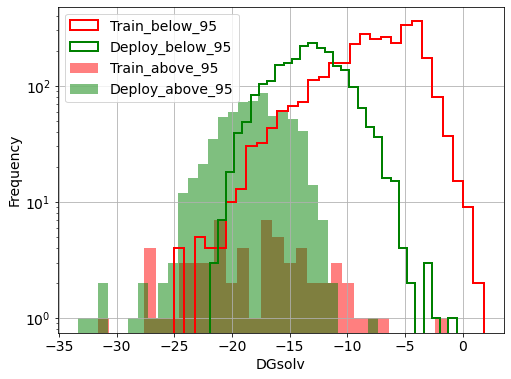

In [45]:
df_dmf_above_95 = df_dmf_dis[df_dmf_dis['above_95_quantile']==1]
df_dmf_below_95 = df_dmf_dis[df_dmf_dis['above_95_quantile']==0]
dff2_above_95 = dff2_dist[dff2_dist['above_95_quantile_train']==1]
dff2_below_95 = dff2_dist[dff2_dist['above_95_quantile_train']==0]
print(f'Number of samples above 95% quantile in df_dmf: {len(df_dmf_above_95)}, percentage: {len(df_dmf_above_95)/len(df_dmf_dis)*100:.2f}%')
print(f'Number of samples below 95% quantile in df_dmf: {len(df_dmf_below_95)}, percentage: {len(df_dmf_below_95)/len(df_dmf_dis)*100:.2f}%')
print(f'Number of samples above 95% quantile in dff2: {len(dff2_above_95)}, percentage: {len(dff2_above_95)/len(dff2_dist)*100:.2f}%')
print(f'Number of samples below 95% quantile in dff2: {len(dff2_below_95)}, percentage: {len(dff2_below_95)/len(dff2_dist)*100:.2f}%')

# plot histogram DGsolv compare df above and below 95% quantile
plt.figure(figsize=(8, 6))
plt.hist(df_dmf_below_95['DGsolv'], bins=30, alpha=1, label='Train_below_95', color='red', histtype='step', linewidth=2)
plt.hist(dff2_below_95['solubility_predicted'], bins=30, alpha=1, label='Deploy_below_95', color='green', histtype='step', linewidth=2)
plt.hist(df_dmf_above_95['DGsolv'], bins=30, alpha=0.5, label='Train_above_95', color='red')
plt.hist(dff2_above_95['solubility_predicted'], bins=30, alpha=0.5, label='Deploy_above_95', color='green')
plt.xlabel('DGsolv')
plt.ylabel('Frequency')
plt.yscale('log')
plt.legend(loc='upper left')
plt.grid()
plt.show()

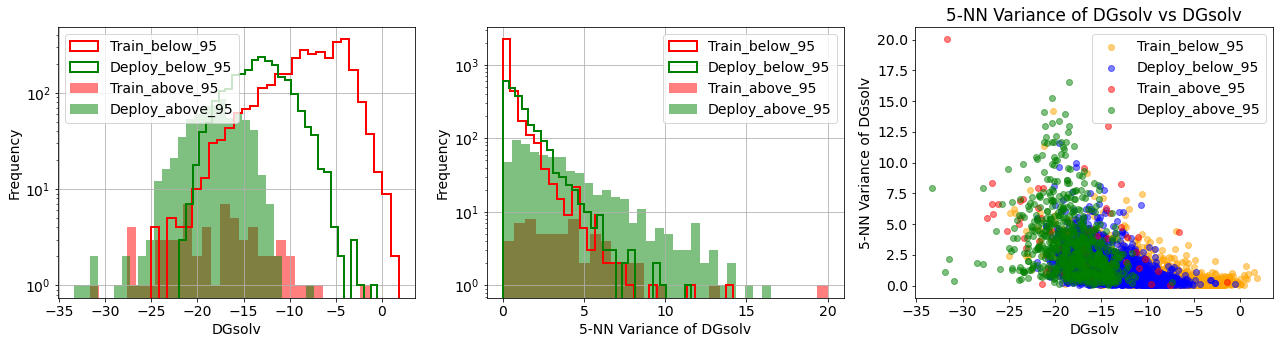

In [46]:
# plot histogram DGsolv compare df above and below 95% quantile
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

axs[0].hist(df_dmf_below_95['DGsolv'], bins=30, alpha=1, label='Train_below_95', color='red', histtype='step', linewidth=2)
axs[0].hist(dff2_below_95['solubility_predicted'], bins=30, alpha=1, label='Deploy_below_95', color='green', histtype='step', linewidth=2)
axs[0].hist(df_dmf_above_95['DGsolv'], bins=30, alpha=0.5, label='Train_above_95', color='red')
axs[0].hist(dff2_above_95['solubility_predicted'], bins=30, alpha=0.5, label='Deploy_above_95', color='green')
axs[0].set_xlabel('DGsolv')
axs[0].set_ylabel('Frequency')
axs[0].set_yscale('log')
axs[0].legend(loc='upper left')
axs[0].grid()       

axs[1].hist(df_dmf_below_95['DGsolv_5NN_var'], bins=30, alpha=1, label='Train_below_95', color='red', histtype='step', linewidth=2)
axs[1].hist(dff2_below_95['DGsolv_5NN_var'], bins=30, alpha=1, label='Deploy_below_95', color='green', histtype='step', linewidth=2)
axs[1].hist(df_dmf_above_95['DGsolv_5NN_var'], bins=30, alpha=0.5, label='Train_above_95', color='red')
axs[1].hist(dff2_above_95['DGsolv_5NN_var'], bins=30, alpha=0.5, label='Deploy_above_95', color='green')
axs[1].set_xlabel('5-NN Variance of DGsolv')
axs[1].set_ylabel('Frequency')
axs[1].set_yscale('log')
axs[1].legend(loc='upper right')
axs[1].grid()

axs[2].scatter(df_dmf_below_95['DGsolv'], df_dmf_below_95['DGsolv_5NN_var'], alpha=0.5, label='Train_below_95', color='orange')
axs[2].scatter(dff2_below_95['solubility_predicted'], dff2_below_95['DGsolv_5NN_var'], alpha=0.5, label='Deploy_below_95', color='blue')
axs[2].scatter(df_dmf_above_95['DGsolv'], df_dmf_above_95['DGsolv_5NN_var'], alpha=0.5, label='Train_above_95', color='red')
axs[2].scatter(dff2_above_95['solubility_predicted'], dff2_above_95['DGsolv_5NN_var'], alpha=0.5, label='Deploy_above_95', color='green')
axs[2].set_xlabel('DGsolv')
axs[2].set_ylabel('5-NN Variance of DGsolv')
axs[2].set_title('5-NN Variance of DGsolv vs DGsolv')
axs[2].legend(loc='upper right')
plt.tight_layout()
plt.show()

<ipython-input-47-041fc475af7c>:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


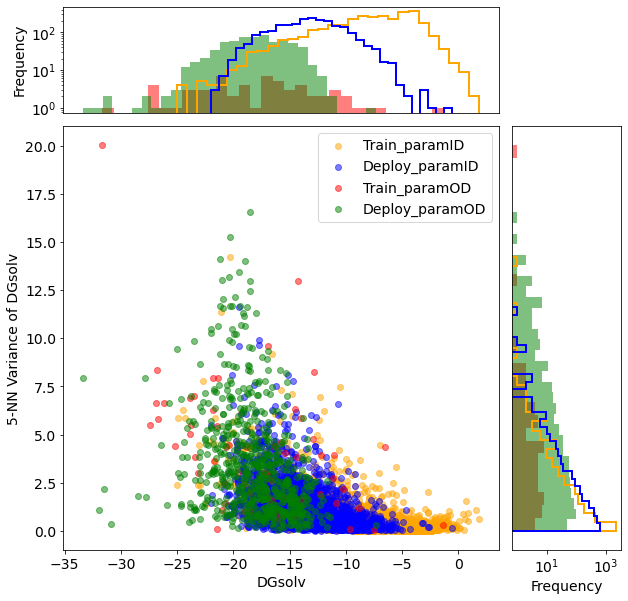

In [47]:
# plot DGsolv vs variance in the center, histograms on top and right
fig = plt.figure(figsize=(10, 10))
gs = fig.add_gridspec(2, 2, width_ratios=(4, 1), height_ratios=(1, 4), wspace=0.05, hspace=0.05)

ax_scatter = fig.add_subplot(gs[1, 0])
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax_scatter)
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax_scatter)

# Scatter plot
ax_histx.hist(df_dmf_below_95['DGsolv'], bins=30, alpha=1, label='Train_below_95', color='orange', histtype='step', linewidth=2)
ax_histx.hist(dff2_below_95['solubility_predicted'], bins=30, alpha=1, label='Deploy_below_95', color='blue', histtype='step', linewidth=2)
ax_histx.hist(df_dmf_above_95['DGsolv'], bins=30, alpha=0.5, label='Train_above_95', color='red')
ax_histx.hist(dff2_above_95['solubility_predicted'], bins=30, alpha=0.5, label='Deploy_above_95', color='green')
ax_histx.set_xlabel('')
ax_histx.xaxis.set_visible(False) 
ax_histx.set_ylabel('Frequency')
ax_histx.set_yscale('log')

ax_histy.hist(df_dmf_below_95['DGsolv_5NN_var'], bins=30, alpha=1, label='Train_below_95', color='orange', histtype='step', linewidth=2, orientation='horizontal')
ax_histy.hist(dff2_below_95['DGsolv_5NN_var'], bins=30, alpha=1, label='Deploy_below_95', color='blue', histtype='step', linewidth=2, orientation='horizontal')
ax_histy.hist(df_dmf_above_95['DGsolv_5NN_var'], bins=30, alpha=0.5, label='Train_above_95', color='red', orientation='horizontal')
ax_histy.hist(dff2_above_95['DGsolv_5NN_var'], bins=30, alpha=0.5, label='Deploy_above_95', color='green', orientation='horizontal')
# ax_histy.set_xlabel('5-NN Variance of DGsolv')
ax_histy.yaxis.set_visible(False) 
ax_histy.set_xlabel('Frequency')
ax_histy.set_xscale('log')

# paramID = within 95% quantile of train-to-train distances in parameter space (molecular embeddings)
# paramOD = outside 95% quantile of train-to-train distances in parameter space (molecular embeddings)
ax_scatter.scatter(df_dmf_below_95['DGsolv'], df_dmf_below_95['DGsolv_5NN_var'], alpha=0.5, label='Train_paramID', color='orange')
ax_scatter.scatter(dff2_below_95['solubility_predicted'], dff2_below_95['DGsolv_5NN_var'], alpha=0.5, label='Deploy_paramID', color='blue')
ax_scatter.scatter(df_dmf_above_95['DGsolv'], df_dmf_above_95['DGsolv_5NN_var'], alpha=0.5, label='Train_paramOD', color='red')
ax_scatter.scatter(dff2_above_95['solubility_predicted'], dff2_above_95['DGsolv_5NN_var'], alpha=0.5, label='Deploy_paramOD', color='green')
ax_scatter.set_xlabel('DGsolv')
ax_scatter.set_ylabel('5-NN Variance of DGsolv')
ax_scatter.legend(loc='upper right')

plt.tight_layout()
plt.show()


### count the full dff2

In [ ]:
df_dmf = pd.read_csv('/home/nanta/Solv_GNN_SSD/data/DMF_as_solvent/Solv_GNN_SSD_train_DMF_as_solvent.csv')

# mark the wholde dff2 for in or out of 95% quantile of distances from df_dmf
dff2f = pd.read_csv('/home/nanta/Redox_mediator_screening/data/Filtered_data/filter2.csv.gz', compression='gzip')
print(len(dff2f))
dff2f = dff2f.sample(n=10000, random_state=42)
# rename columns for consistency
dff2f.rename(columns={'predicted': 'solubility_predicted'}, inplace=True)
dff2f = dff2f[['can_smiles_solute','can_smiles_solvent','DGsolv','solubility_predicted']]

# Load model and preprocessor
model = tf.keras.models.load_model('/home/nanta/Solv_GNN_SSD/model_files/SSD_models/student35/best_model.h5', custom_objects=nfp.custom_objects)
preprocessor = CustomPreprocessor(explicit_hs=False, atom_features=atom_features, bond_features=bond_features)
preprocessor.from_json('/home/nanta/Solv_GNN_SSD/model_files/SSD_models/student35/preprocessor.json')

extractor = tf.keras.Model(model.inputs, [model.get_layer('dense_22').input]) # layer after all message passing and then tf.concat
output_signature = (preprocessor.output_signature, tf.TensorSpec(shape=(), dtype=tf.float32), tf.TensorSpec(shape=(), dtype=tf.float32))

def embed_dataframe(df):
    ds = tf.data.Dataset.from_generator(
        lambda: create_tf_dataset(df, preprocessor, 1.0, False),
        output_signature=output_signature
    ).padded_batch(batch_size=len(df))
    # Use tqdm to show progress bar during prediction
    embedding = extractor.predict(ds, verbose=1)  # verbose=1 shows a progress bar
    embedding = embedding.squeeze()
    # select only the first 128 features (solute)
    embedding = embedding[:, :128]
    return pd.DataFrame(embedding, index=df.index)

# embed df_dmf
emb_dmf = embed_dataframe(df_dmf)
nn = NearestNeighbors(n_neighbors=5, metric='euclidean')
nn.fit(emb_dmf)
# calculate distances to df_dmf
distances_dmf, indices_dmf = nn.kneighbors(emb_dmf)
quan_95_dmf = np.quantile(distances_dmf, 0.95)
print(f'95% quantile of distances_dmf: {quan_95_dmf}')

/home/nanta/miniconda3/envs/tf24gpu/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3398: DtypeWarning: Columns (31,38) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


635217
1/1 [==============================] - 14s 14s/step
95% quantile of distances_dmf: 19.921843338012692


In [59]:
# chunking dff2f to avoid memory issues
chunk_size = 20000  # Adjust based on your memory capacity
dff2f_chunks = [dff2f[i:i + chunk_size] for i in range(0, len(dff2f), chunk_size)]  
# Initialize an empty DataFrame to store results
dff2f_results = pd.DataFrame()  

for chunk in tqdm(dff2f_chunks, desc="Processing chunks"):
    emb_chunk = embed_dataframe(chunk)
    nn_chunk = NearestNeighbors(n_neighbors=5, metric='euclidean')
    nn_chunk.fit(emb_dmf)
    distances_chunk, indices_chunk = nn_chunk.kneighbors(emb_chunk)
    
    # Calculate mean and variance of DGsolv for the 5 nearest neighbors
    nn_dgsolv = df_dmf['DGsolv'].values[indices_chunk.flatten()]
    nn_dgsolv = nn_dgsolv.reshape(distances_chunk.shape)
    nn_dgsolv_mean = nn_dgsolv.mean(axis=1)
    nn_dgsolv_var = nn_dgsolv.var(axis=1)

    # Create a DataFrame for the chunk results
    chunk_results = pd.DataFrame({
        'can_smiles_solute': chunk['can_smiles_solute'],
        'can_smiles_solvent': chunk['can_smiles_solvent'],
        'DGsolv': chunk['DGsolv'],
        'solubility_predicted': chunk['solubility_predicted'],
        'distance_to_train': distances_chunk.mean(axis=1),
        'above_95_quantile_train': (distances_chunk.mean(axis=1) > quan_95_dmf).astype(int),
        'DGsolv_5NN': nn_dgsolv_mean,
        'DGsolv_5NN_var': nn_dgsolv_var
    })
    
    # Append the chunk results to the main DataFrame
    dff2f_results = pd.concat([dff2f_results, chunk_results], ignore_index=True)

# Save the results to a CSV file
dff2f_results.to_csv('/home/nanta/Solv_GNN_SSD/data/DMF_as_solvent/filter1_pre_sol_pred_results_with_distances.csv.gz', compression='gzip', index=False)


Processing chunks:   0%|          | 0/1 [00:00<?, ?it/s]

1/1 [==============================] - 46s 46s/step


Processing chunks: 100%|██████████| 1/1 [00:46<00:00, 46.96s/it]


In [ ]:
# load data processed using file potential_OOD_v2.py
df = pd.read_csv('/home/nanta/Solv_GNN_SSD/data/DMF_as_solvent/filter2_with_distances.csv.gz', compression='gzip')
print(len(df))
print(df.head())

635212
                         can_smiles_solute can_smiles_solvent  DGsolv  \
0                 C1=CC(C(C(=C1)C(=O)O)O)O           CN(C)C=O     NaN   
1                     C(C(=O)COP(=O)(O)O)N           CN(C)C=O     NaN   
2  CCCCCC(=O)C=CC1C(CC(=O)C1CCCCCCC(=O)O)O           CN(C)C=O     NaN   
3                C1=CC(=C(C(=C1)O)O)C(=O)O           CN(C)C=O     NaN   
4                     CCC(C(=O)C)(C(=O)O)O           CN(C)C=O     NaN   

   solubility_predicted  distance_to_train  above_95_quantile_train  \
0            -15.368717          19.029266                        0   
1            -19.114243          20.469942                        1   
2            -24.575998          27.876972                        1   
3            -15.041539          15.490588                        0   
4            -14.629997          17.660181                        0   

   DGsolv_5NN  DGsolv_5NN_var  
0  -14.762117        5.846425  
1  -18.026111        7.300948  
2  -20.330958        8.123776  

In [74]:
print(f'Number of samples above 95% quantile in dff2f: {len(dff2f_results[dff2f_results["above_95_quantile_train"]==1])}, percentage: {len(dff2f_results[dff2f_results["above_95_quantile_train"]==1]) / len(dff2f_results) * 100:.2f}%')
print(f'Number of samples below 95% quantile in dff2f: {len(dff2f_results[dff2f_results["above_95_quantile_train"]==0])}, percentage: {len(dff2f_results[dff2f_results["above_95_quantile_train"]==0]) / len(dff2f_results) * 100:.2f}%')

Number of samples above 95% quantile in dff2f: 2294, percentage: 22.94%
Number of samples below 95% quantile in dff2f: 7706, percentage: 77.06%


In [75]:
print(f'Number of samples above 95% quantile in dff2f: {len(df[df["above_95_quantile_train"]==1])}, percentage: {len(df[df["above_95_quantile_train"]==1]) / len(df) * 100:.2f}%')
print(f'Number of samples below 95% quantile in dff2f: {len(df[df["above_95_quantile_train"]==0])}, percentage: {len(df[df["above_95_quantile_train"]==0]) / len(df) * 100:.2f}%')

Number of samples above 95% quantile in dff2f: 145908, percentage: 22.97%
Number of samples below 95% quantile in dff2f: 489304, percentage: 77.03%


# plot DGSolv comparing exp, aug, predicted


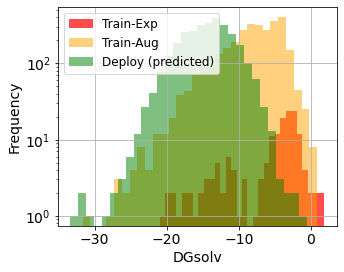

In [68]:
dfexp = pd.read_csv('/home/nanta/Solv_GNN_SSD/data/Exp-DB-DMF.csv')
dfaug = pd.read_csv('/home/nanta/Solv_GNN_SSD/data/Aug-DB-DMF.csv')

# plot hitogram DGSolv comparing exp, aug, predicted
fig, axs = plt.subplots(1, 1, figsize=(5, 4))
axs.tick_params(axis='both', labelsize=14)

axs.hist(dfexp['DGsolv'], bins=30, alpha=0.7, label='Train-Exp', color='red')
axs.hist(dfaug['DGsolv'], bins=30, alpha=0.5, label='Train-Aug', color='orange')
axs.hist(dff2['solubility_predicted'], bins=30, alpha=0.5, label='Deploy (predicted)', color='green')
axs.set_xlabel('DGsolv', fontsize=14)
axs.set_ylabel('Frequency', fontsize=14)
# logscale y axis
axs.set_yscale('log')
# axs.set_title('Distribution of DGsolv (Exp, Aug, Predicted)')
axs.legend(fontsize=12, loc='upper left')
axs.grid()  
plt.tight_layout()
plt.show()

## [Archive] t-SNE plot

In [63]:
'''
# t-SNE comparison
all_emb = np.concatenate([emb_aug, emb_dff2])
labels = np.array([0]*len(emb_aug) + [1]*len(emb_dff2))
pipe = Pipeline(steps=[('PCA', PCA(n_components=10)), ('TSNE', TSNE(n_components=2, random_state=0))])
tsne_coords = pipe.fit_transform(all_emb)
plt.figure(figsize=(6,5))
plt.scatter(tsne_coords[labels==0,0], tsne_coords[labels==0,1], s=10, label='DMF as solvent', alpha=0.5)
plt.scatter(tsne_coords[labels==1,0], tsne_coords[labels==1,1], s=10, label='dff2', alpha=0.5, c='orange')
plt.legend()
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('Embedding distribution comparison')
plt.show()

# save figure
plt.savefig('/home/nanta/Solv_GNN_SSD/notebooks/embedding_comparison.png', dpi=300, bbox_inches='tight')
'''

"\n# t-SNE comparison\nall_emb = np.concatenate([emb_aug, emb_dff2])\nlabels = np.array([0]*len(emb_aug) + [1]*len(emb_dff2))\npipe = Pipeline(steps=[('PCA', PCA(n_components=10)), ('TSNE', TSNE(n_components=2, random_state=0))])\ntsne_coords = pipe.fit_transform(all_emb)\nplt.figure(figsize=(6,5))\nplt.scatter(tsne_coords[labels==0,0], tsne_coords[labels==0,1], s=10, label='DMF as solvent', alpha=0.5)\nplt.scatter(tsne_coords[labels==1,0], tsne_coords[labels==1,1], s=10, label='dff2', alpha=0.5, c='orange')\nplt.legend()\nplt.xlabel('t-SNE 1')\nplt.ylabel('t-SNE 2')\nplt.title('Embedding distribution comparison')\nplt.show()\n\n# save figure\nplt.savefig('/home/nanta/Solv_GNN_SSD/notebooks/embedding_comparison.png', dpi=300, bbox_inches='tight')\n"

In [64]:
# len(emb_aug[0])

## [Archive] Cosine similarity

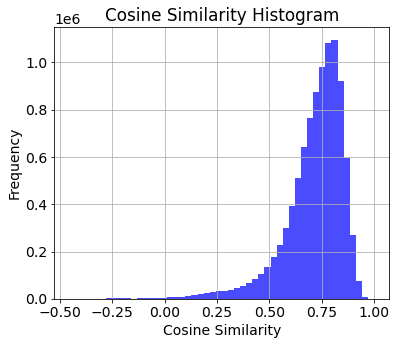

In [65]:
# cosine similarity
from sklearn.metrics.pairwise import cosine_similarity
cos_sim = cosine_similarity(emb_dmf, emb_dff2)

# plot cosine similarity histogram
plt.figure(figsize=(6,5))
plt.hist(cos_sim.flatten(), bins=50, alpha=0.7, color='blue')
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
plt.title('Cosine Similarity Histogram')
plt.grid()
plt.show()


In [66]:
# count when cosine similarity is below 0.5
count_below_05 = np.sum(cos_sim < 0.5)
print(f'Number of pairs with cosine similarity below 0.5: {count_below_05}')
print(f'Percentage of pairs with cosine similarity below 0.5: {count_below_05 / cos_sim.size * 100:.2f}%')

Number of pairs with cosine similarity below 0.5: 708983
Percentage of pairs with cosine similarity below 0.5: 7.34%


In [67]:
# get indices of dff2 with cosine similarity below 0.5
indices_below_05 = np.argwhere(cos_sim < 0.5)
# print indices
print(f'Indices of dff2 with cosine similarity below 0.5: {indices_below_05}')

# store indices in a file
with open('/home/nanta/Solv_GNN_SSD/notebooks/test_below_05_gnn_cosinesim.txt', 'w') as f:
    for i, j in indices_below_05:
        f.write(f'{j}\n')

Indices of dff2 with cosine similarity below 0.5: [[   0 1454]
 [   0 2824]
 [   1    0]
 ...
 [3217 2592]
 [3217 2824]
 [3217 2955]]


# Compare fingerprint

## k-NN tanimoto distance

In [ ]:
# # ERFP4 fingerprint
# from rdkit import Chem
# from rdkit.Chem import AllChem

# def get_erfp4_fingerprint(smiles):
#     mol = Chem.MolFromSmiles(smiles)
#     if mol is None:
#         return None
#     # fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048, useFeatures=True)
#     fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
#     return np.array(fp)

# # Create ERFP4 fingerprints for dff2
# dff2['erfp4'] = dff2['can_smiles_solute'].apply(get_erfp4_fingerprint)
# # Filter out None fingerprints
# dff3 = dff2[dff2['erfp4'].notnull()]
# print(f'Number of valid ERFP4 fingerprints: {len(dff3)}')
# # Convert to numpy array
# dff2_fps = np.array(dff3['erfp4'].tolist())    
# print(dff2_fps.shape)

# # create ERFP4 fingerprints for df_dmf
# df_dmf['erfp4'] = df_dmf['can_smiles_solute'].apply(get_erfp4_fingerprint)
# # Filter out None fingerprints
# df_dmf_fps = df_dmf[df_dmf['erfp4'].notnull()]
# print(f'Number of valid ERFP4 fingerprints in df_dmf: {len(df_dmf_fps)}')
# # Convert to numpy array
# df_dmf_fps = np.array(df_dmf_fps['erfp4'].tolist())    
# print(df_dmf_fps.shape)


Number of valid ERFP4 fingerprints: 3000
(3000, 2048)
Number of valid ERFP4 fingerprints in df_dmf: 3218
(3218, 2048)


In [3]:
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
import numpy as np

mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2,fpSize=2048)

df_dmf_fps = np.array([np.array(mfpgen.GetFingerprint(Chem.MolFromSmiles(smiles))) 
                     for smiles in df_dmf['can_smiles_solute'] if Chem.MolFromSmiles(smiles) is not None])
print(len(df_dmf_fps))

dff2_fps = np.array([np.array(mfpgen.GetFingerprint(Chem.MolFromSmiles(smiles))) 
                    for smiles in dff2['can_smiles_solute'] if Chem.MolFromSmiles(smiles) is not None])
print(len(dff2_fps))

3218
3000


In [25]:
print(df_dmf_fps[0][0:1000])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 1 0 0 0 0 0 0 0 

/home/nanta/miniconda3/envs/tf24gpu/lib/python3.8/site-packages/sklearn/metrics/pairwise.py:1776: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


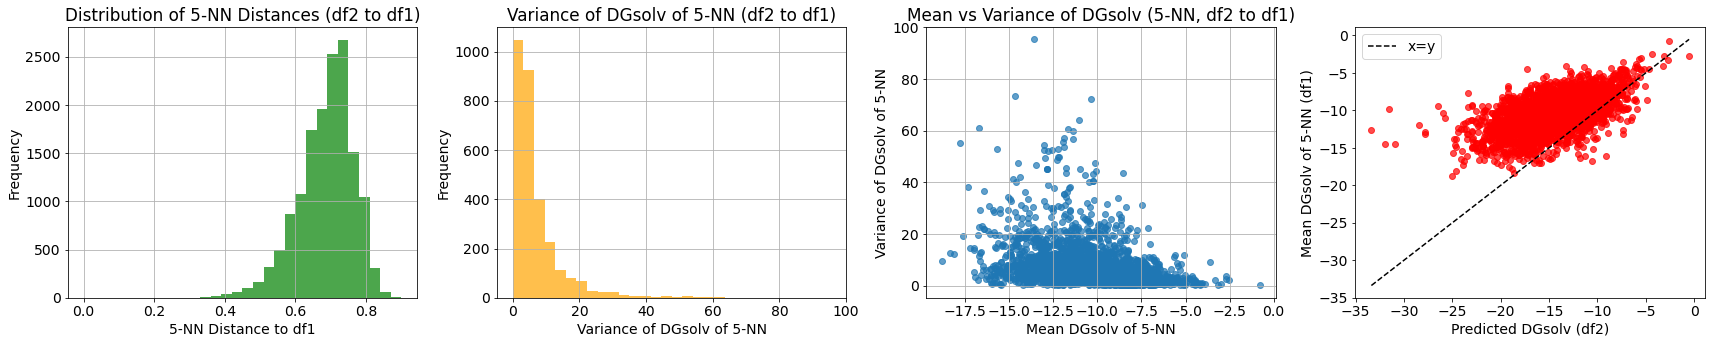

In [18]:
# k-NN tanimoto distance
from sklearn.neighbors import NearestNeighbors
def kNN_tanimoto_plot(emb1, emb2, df1, df2, n_neighbors=5):
    nn = NearestNeighbors(n_neighbors=n_neighbors, metric='jaccard')
    nn.fit(emb1)
    distances, indices = nn.kneighbors(emb2)

    nn_dgsolv = df1['DGsolv'].values[indices.flatten()]
    nn_dgsolv = nn_dgsolv.reshape(distances.shape)
    nn_dgsolv_mean = nn_dgsolv.mean(axis=1)
    nn_dgsolv_var = nn_dgsolv.var(axis=1)   
    nn_distances_mean = distances.mean(axis=1)

    fig, axs = plt.subplots(1, 4, figsize=(24, 5))

    # Plot distribution of the 5-NN distances (flattened)
    axs[0].hist(distances.flatten(), bins=30, alpha=0.7, color='green')
    # axs[0].hist(nn_distances_mean, bins=30, alpha=0.7, color='green', edgecolor='black')
    axs[0].set_xlabel(f'{n_neighbors}-NN Distance to df1')
    axs[0].set_ylabel('Frequency')
    axs[0].set_title('Distribution of 5-NN Distances (df2 to df1)')
    axs[0].grid()

    # Plot variance of DGsolv of the 5 nearest neighbors
    axs[1].hist(nn_dgsolv_var, bins=30, alpha=0.7, color='orange')
    axs[1].set_xlabel('Variance of DGsolv of 5-NN')
    axs[1].set_ylabel('Frequency')
    axs[1].set_title('Variance of DGsolv of 5-NN (df2 to df1)')
    axs[1].grid()

    # Plot mean vs variance of DGsolv of the 5 nearest neighbors
    axs[2].scatter(nn_dgsolv_mean, nn_dgsolv_var, alpha=0.7)
    axs[2].set_xlabel('Mean DGsolv of 5-NN')
    axs[2].set_ylabel('Variance of DGsolv of 5-NN')
    axs[2].set_title('Mean vs Variance of DGsolv (5-NN, df2 to df1)')
    axs[2].grid()

    if 'solubility_predicted' in df2.columns:
        # plot the solubility_predicted of df2 vs mean of the 5-NN
        axs[3].scatter(df2['solubility_predicted'].values, nn_dgsolv_mean, alpha=0.7, color='red')
        axs[3].set_xlabel('Predicted DGsolv (df2)')
        axs[3].set_ylabel('Mean DGsolv of 5-NN (df1)')
        axs[3].legend(['5-NN Mean', 'True Values'], loc='upper left')   
        axs[3].plot(
            [df2['solubility_predicted'].min(), df2['solubility_predicted'].max()],
            [df2['solubility_predicted'].min(), df2['solubility_predicted'].max()],
            'k--', label='x=y'
        )
    else:
        # plot the DGsolv of df2 vs mean of the 5-NN
        axs[3].scatter(df2['DGsolv'].values, nn_dgsolv_mean, alpha=0.7, color='red')
        axs[3].set_xlabel('DGsolv (df2)')
        axs[3].set_ylabel('Mean DGsolv of 5-NN (df1)')
        axs[3].legend(['5-NN Mean', 'True Values'], loc='upper left')   
        axs[3].plot(
            [df2['DGsolv'].min(), df2['DGsolv'].max()],
            [df2['DGsolv'].min(), df2['DGsolv'].max()],
            'k--', label='x=y'
        )
    axs[3].legend()     
    plt.tight_layout()
    plt.show()

kNN_tanimoto_plot(df_dmf_fps, dff2_fps, df_dmf, dff2, n_neighbors=5)

/home/nanta/miniconda3/envs/tf24gpu/lib/python3.8/site-packages/sklearn/metrics/pairwise.py:1776: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


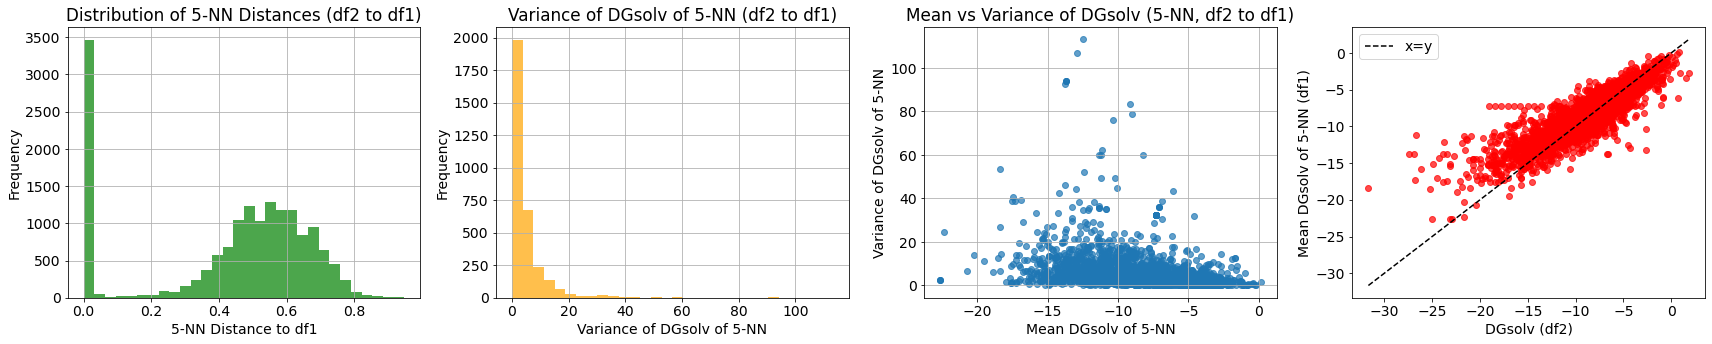

In [19]:
kNN_tanimoto_plot(df_dmf_fps, df_dmf_fps, df_dmf, df_dmf, n_neighbors=5)

## compare

/home/nanta/miniconda3/envs/tf24gpu/lib/python3.8/site-packages/sklearn/metrics/pairwise.py:1776: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


95% quantile of distances_self: 0.7272727272727273


/home/nanta/miniconda3/envs/tf24gpu/lib/python3.8/site-packages/sklearn/metrics/pairwise.py:1776: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


95% quantile of distances_other: 0.7878126672986008


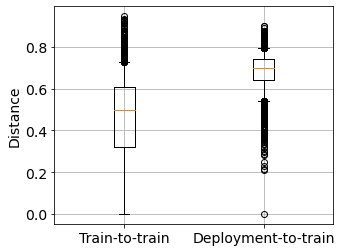

In [17]:
# boxplot comparing distance to self and distance to df2
def boxplot_distance(fps1, fps2, df1, df2, n_neighbors=5):
    nn_self = NearestNeighbors(n_neighbors=n_neighbors, metric='jaccard')
    nn_self.fit(fps1)
    distances_self, index = nn_self.kneighbors(fps1)
    quan_95 = np.quantile(distances_self, 0.95)
    print(f'95% quantile of distances_self: {quan_95}')
    df1 = df1.copy()
    df1['distance_to_train'] = distances_self.mean(axis=1)
    # quan_95 = np.quantile(df1['distance_to_train'], 0.95)
    # print(f'95% quantile of distances_self: {quan_95}')
    df1['above_95_quantile'] = (df1['distance_to_train'] > quan_95).astype(int)
    df1['DGsolv_5NN'] = df1['DGsolv'].values[index.flatten()].reshape(distances_self.shape).mean(axis=1)
    df1['DGsolv_5NN_var'] = df1['DGsolv'].values[index.flatten()].reshape(distances_self.shape).var(axis=1)

    nn_other = NearestNeighbors(n_neighbors=n_neighbors, metric='jaccard')
    nn_other.fit(fps1)
    distances_other, index_o = nn_other.kneighbors(fps2)
    # print(f'95% quantile of distances_other: {np.quantile(distances_other, 0.95)}')
    df2 = df2.copy()
    df2['distance_to_train'] = distances_other.mean(axis=1)
    print(f'95% quantile of distances_other: {np.quantile(df2["distance_to_train"], 0.95)}')
    df2['above_95_quantile_train'] = (df2['distance_to_train'] > quan_95).astype(int)
    df2['DGsolv_5NN'] = df1['DGsolv'].values[index_o.flatten()].reshape(distances_other.shape).mean(axis=1)
    df2['DGsolv_5NN_var'] = df1['DGsolv'].values[index_o.flatten()].reshape(distances_other.shape).var(axis=1)

    distances_self_flat = distances_self.flatten()
    distances_other_flat = distances_other.flatten()

    plt.rcParams.update({'font.size': 14})
    plt.figure(figsize=(5, 4))
    plt.boxplot([distances_self_flat, distances_other_flat], labels=['Train-to-train', 'Deployment-to-train'], whis=(5,95))
    # plt.boxplot([df1['distance_to_train'], df2['distance_to_train']], labels=['Train-to-train', 'Deployment-to-train'], whis=(5,95))
    plt.ylabel('Distance')
    plt.grid()
    plt.show()

    return df1, df2


df_dmf_dis, dff2_dist = boxplot_distance(df_dmf_fps, dff2_fps, df_dmf, dff2, n_neighbors=5)

Number of samples above 95% quantile in df_dmf: 3, percentage: 0.09%
Number of samples below 95% quantile in df_dmf: 3215, percentage: 99.91%
Number of samples above 95% quantile in dff2: 906, percentage: 30.20%
Number of samples below 95% quantile in dff2: 2094, percentage: 69.80%


<ipython-input-20-5735013c7dac>:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


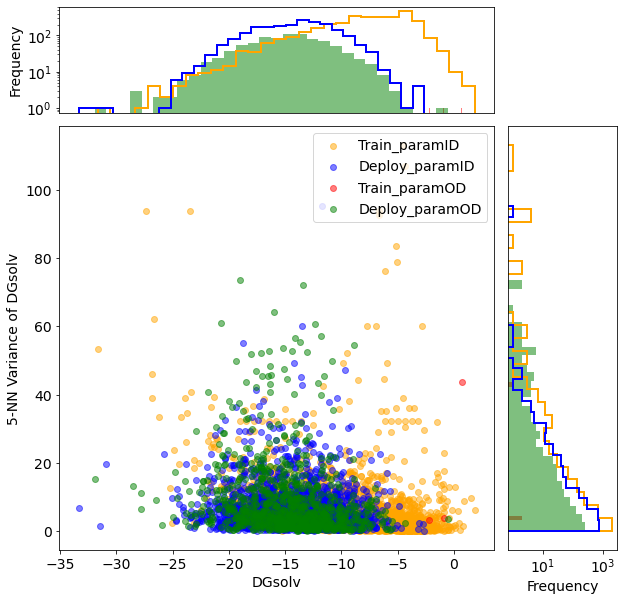

In [20]:
# plot DGsolv vs variance in the center, histograms on top and right
def plot_dgsolv_vs_variance(df_dmf_dis, dff2_dist):

    df_dmf_above_95 = df_dmf_dis[df_dmf_dis['above_95_quantile']==1]
    df_dmf_below_95 = df_dmf_dis[df_dmf_dis['above_95_quantile']==0]
    dff2_above_95 = dff2_dist[dff2_dist['above_95_quantile_train']==1]
    dff2_below_95 = dff2_dist[dff2_dist['above_95_quantile_train']==0]
    print(f'Number of samples above 95% quantile in df_dmf: {len(df_dmf_above_95)}, percentage: {len(df_dmf_above_95)/len(df_dmf_dis)*100:.2f}%')
    print(f'Number of samples below 95% quantile in df_dmf: {len(df_dmf_below_95)}, percentage: {len(df_dmf_below_95)/len(df_dmf_dis)*100:.2f}%')
    print(f'Number of samples above 95% quantile in dff2: {len(dff2_above_95)}, percentage: {len(dff2_above_95)/len(dff2_dist)*100:.2f}%')
    print(f'Number of samples below 95% quantile in dff2: {len(dff2_below_95)}, percentage: {len(dff2_below_95)/len(dff2_dist)*100:.2f}%')

    # plot DGsolv vs variance in the center, histograms on top and right
    plt.rcParams.update({'font.size': 14})
    fig = plt.figure(figsize=(10, 10))
    gs = fig.add_gridspec(2, 2, width_ratios=(4, 1), height_ratios=(1, 4), wspace=0.05, hspace=0.05)

    ax_scatter = fig.add_subplot(gs[1, 0])
    ax_histx = fig.add_subplot(gs[0, 0], sharex=ax_scatter)
    ax_histy = fig.add_subplot(gs[1, 1], sharey=ax_scatter)

    # Scatter plot
    ax_histx.hist(df_dmf_below_95['DGsolv'], bins=30, alpha=1, label='Train_below_95', color='orange', histtype='step', linewidth=2)
    ax_histx.hist(dff2_below_95['solubility_predicted'], bins=30, alpha=1, label='Deploy_below_95', color='blue', histtype='step', linewidth=2)
    ax_histx.hist(df_dmf_above_95['DGsolv'], bins=30, alpha=0.5, label='Train_above_95', color='red')
    ax_histx.hist(dff2_above_95['solubility_predicted'], bins=30, alpha=0.5, label='Deploy_above_95', color='green')
    ax_histx.set_xlabel('')
    ax_histx.xaxis.set_visible(False) 
    ax_histx.set_ylabel('Frequency')
    ax_histx.set_yscale('log')

    ax_histy.hist(df_dmf_below_95['DGsolv_5NN_var'], bins=30, alpha=1, label='Train_below_95', color='orange', histtype='step', linewidth=2, orientation='horizontal')
    ax_histy.hist(dff2_below_95['DGsolv_5NN_var'], bins=30, alpha=1, label='Deploy_below_95', color='blue', histtype='step', linewidth=2, orientation='horizontal')
    ax_histy.hist(df_dmf_above_95['DGsolv_5NN_var'], bins=30, alpha=0.5, label='Train_above_95', color='red', orientation='horizontal')
    ax_histy.hist(dff2_above_95['DGsolv_5NN_var'], bins=30, alpha=0.5, label='Deploy_above_95', color='green', orientation='horizontal')
    # ax_histy.set_xlabel('5-NN Variance of DGsolv')
    ax_histy.yaxis.set_visible(False) 
    ax_histy.set_xlabel('Frequency')
    ax_histy.set_xscale('log')

    # paramID = within 95% quantile of train-to-train distances in parameter space (molecular embeddings)
    # paramOD = outside 95% quantile of train-to-train distances in parameter space (molecular embeddings)
    ax_scatter.scatter(df_dmf_below_95['DGsolv'], df_dmf_below_95['DGsolv_5NN_var'], alpha=0.5, label='Train_paramID', color='orange')
    ax_scatter.scatter(dff2_below_95['solubility_predicted'], dff2_below_95['DGsolv_5NN_var'], alpha=0.5, label='Deploy_paramID', color='blue')
    ax_scatter.scatter(df_dmf_above_95['DGsolv'], df_dmf_above_95['DGsolv_5NN_var'], alpha=0.5, label='Train_paramOD', color='red')
    ax_scatter.scatter(dff2_above_95['solubility_predicted'], dff2_above_95['DGsolv_5NN_var'], alpha=0.5, label='Deploy_paramOD', color='green')
    ax_scatter.set_xlabel('DGsolv')
    ax_scatter.set_ylabel('5-NN Variance of DGsolv')
    ax_scatter.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

plot_dgsolv_vs_variance(df_dmf_dis, dff2_dist)

/home/nanta/miniconda3/envs/tf24gpu/lib/python3.8/site-packages/sklearn/metrics/pairwise.py:1776: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


95% quantile of distances_self: 0.3422180451127817


/home/nanta/miniconda3/envs/tf24gpu/lib/python3.8/site-packages/sklearn/metrics/pairwise.py:1776: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


95% quantile of distances_other: 0.7741250431376481


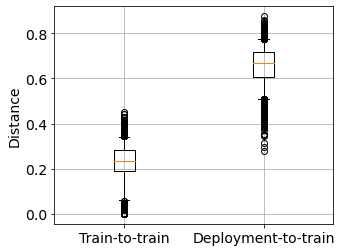

In [10]:
df_dmf_dis, dff2_dist = boxplot_distance(df_dmf_fps, dff2_fps, df_dmf, dff2, n_neighbors=2)

Number of samples above 95% quantile in df_dmf: 161, percentage: 5.00%
Number of samples below 95% quantile in df_dmf: 3057, percentage: 95.00%
Number of samples above 95% quantile in dff2: 2997, percentage: 99.90%
Number of samples below 95% quantile in dff2: 3, percentage: 0.10%


<ipython-input-8-5735013c7dac>:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


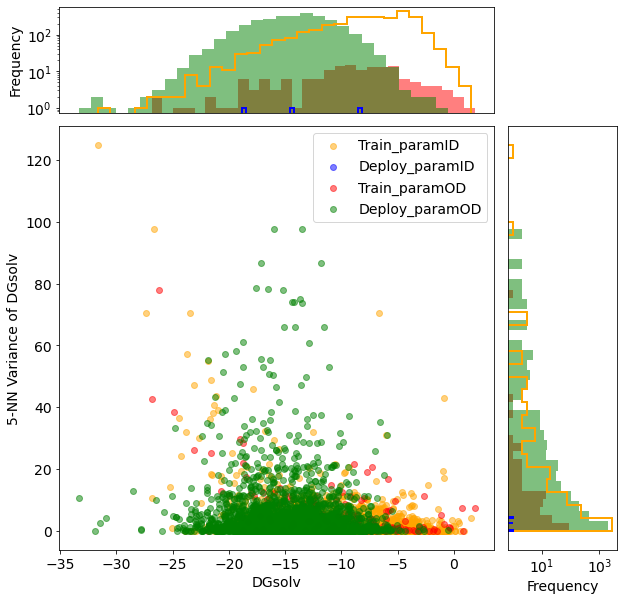

In [11]:
plot_dgsolv_vs_variance(df_dmf_dis, dff2_dist)

/home/nanta/miniconda3/envs/tf24gpu/lib/python3.8/site-packages/sklearn/metrics/pairwise.py:1776: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


95% quantile of distances_self: 0.6749084914726319


/home/nanta/miniconda3/envs/tf24gpu/lib/python3.8/site-packages/sklearn/metrics/pairwise.py:1776: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


95% quantile of distances_other: 0.8015818960623792


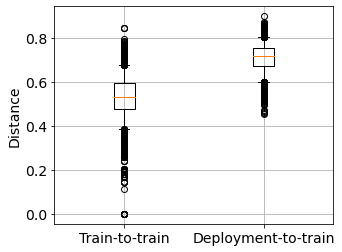

In [12]:
df_dmf_dis, dff2_dist = boxplot_distance(df_dmf_fps, dff2_fps, df_dmf, dff2, n_neighbors=10)

Number of samples above 95% quantile in df_dmf: 161, percentage: 5.00%
Number of samples below 95% quantile in df_dmf: 3057, percentage: 95.00%
Number of samples above 95% quantile in dff2: 2197, percentage: 73.23%
Number of samples below 95% quantile in dff2: 803, percentage: 26.77%


<ipython-input-8-5735013c7dac>:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


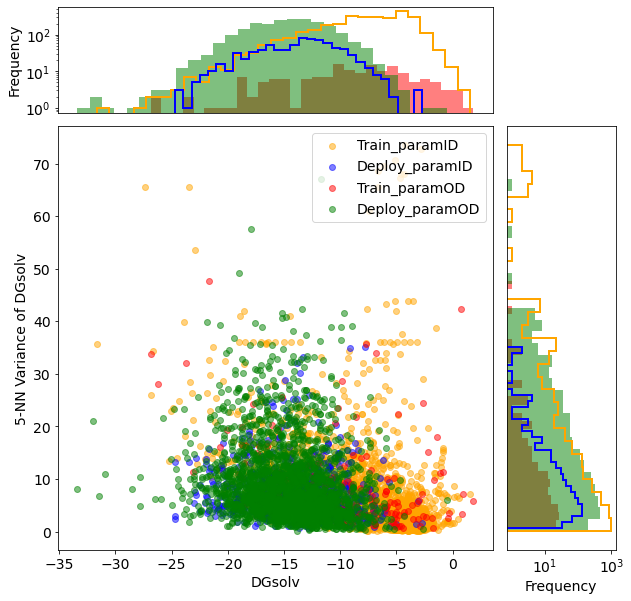

In [14]:
plot_dgsolv_vs_variance(df_dmf_dis, dff2_dist)

## count the full dff2

In [ ]:
# load fingerprints (1 min)
# load the fingerprints
train_fps = np.load('/home/nanta/Solv_GNN_SSD/data/DMF_as_solvent/train_solute_fps.npy')
test_fps = np.load('/home/nanta/Solv_GNN_SSD/data/DMF_as_solvent/test_smiles_fps.npy')


In [84]:
dff2fps = pd.read_csv('/home/nanta/Redox_mediator_screening/data/Filtered_data/filter2.csv.gz', compression='gzip')


/home/nanta/miniconda3/envs/tf24gpu/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3398: DtypeWarning: Columns (32,39) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [ ]:
df_dmf_fps = pd.read_csv('/home/nanta/Solv_GNN_SSD/data/DMF_as_solvent/Solv_GNN_SSD_train_DMF_as_solvent.csv')
print(f'Number of samples in df_dmf_fps: {len(df_dmf_fps)}')
df_dmf_fps = df_dmf_fps.sample(n=3000, random_state=42)

Number of samples in df_dmf_fps: 3218


In [85]:
print(len(train_fps), len(test_fps))

3218 635212


In [86]:
print(len(dff2fps))

635212


In [ ]:
from sklearn.neighbors import NearestNeighbors

# 5-NN Tanimoto distance from train to train
nn = NearestNeighbors(n_neighbors=5, metric='jaccard')
nn.fit(train_fps)
distances, indices = nn.kneighbors(train_fps)
quan_95_tanimoto = np.quantile(distances, 0.95)
print(f'95% quantile of Tanimoto distances: {quan_95_tanimoto}')

# 5-NN Tanimoto distance from test to train
# create chunk of test data
chunk_size = 20000  # Adjust based on your memory capacity
test_chunks = [test_fps[i:i + chunk_size] for i in range(0, len(test_fps), chunk_size)]  
dff2_chunks = [dff2fps[i:i + chunk_size] for i in range(0, len(dff2fps), chunk_size)]
# Initialize an empty DataFrame to store results
results = pd.DataFrame()

for chunk, dff in tqdm(zip(test_chunks, dff2_chunks), desc="Processing test chunks"):
    # Calculate distances and indices for the chunk
    distances_chunk, indices_chunk = nn.kneighbors(chunk)

    # Calculate mean and variance of DGsolv for the 5 nearest neighbors
    nn_dgsolv = df_dmf_fps['DGsolv'].values[indices_chunk.flatten()]
    nn_dgsolv = nn_dgsolv.reshape(distances_chunk.shape)
    nn_dgsolv_mean = nn_dgsolv.mean(axis=1)
    nn_dgsolv_var = nn_dgsolv.var(axis=1)

    print(f'Processing chunk of size {len(dff)}')

    # Create a DataFrame for the chunk results
    chunk_results = pd.DataFrame({
        'can_smiles_solute': dff['can_smiles_solute'],
        'can_smiles_solvent': dff['can_smiles_solvent'],
        'DGsolv': dff['DGsolv'],
        'solubility_predicted': dff['solubility_predicted'],
        'distance_to_train': distances_chunk.mean(axis=1),
        'above_95_quantile_train': (distances_chunk.mean(axis=1) > quan_95_tanimoto).astype(int),
        'DGsolv_5NN': nn_dgsolv_mean,
        'DGsolv_5NN_var': nn_dgsolv_var
    })
    
    # Append the chunk results to the main DataFrame
    results = pd.concat([results, chunk_results], ignore_index=True)

print(f'Number of samples above 95% quantile in test: {len(results[results["above_95_quantile_train"]==1])}, percentage: {len(results[results["above_95_quantile_train"]==1]) / len(results) * 100:.2f}%')
print(f'Number of samples below 95% quantile in test: {len(results[results["above_95_quantile_train"]==0])}, percentage: {len(results[results["above_95_quantile_train"]==0]) / len(results) * 100:.2f}%')

In [4]:
# load results run by file potential_OOD_fps.py
df = pd.read_csv('/home/nanta/Solv_GNN_SSD/data/DMF_as_solvent/filter2_with_distances_fps.csv.gz', compression='gzip')
print(f'Number of samples in results: {len(df)}')

Number of samples in results: 635212


In [5]:
print(f'Number of samples above 95% quantile in dff2f: {len(df[df["above_95_quantile_train"]==1])}, percentage: {len(df[df["above_95_quantile_train"]==1]) / len(df) * 100:.2f}%')
print(f'Number of samples below 95% quantile in dff2f: {len(df[df["above_95_quantile_train"]==0])}, percentage: {len(df[df["above_95_quantile_train"]==0]) / len(df) * 100:.2f}%')

Number of samples above 95% quantile in dff2f: 192255, percentage: 30.27%
Number of samples below 95% quantile in dff2f: 442957, percentage: 69.73%
